In [1]:
# =====================================================
# CELL 1 - IMPORT LIBRARY
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
pd.set_option('display.max_columns', None)

print("Library berhasil diimport.")

Library berhasil diimport.


In [2]:
# =====================================================
# CELL 2 - LOAD DATASET
# =====================================================

df = pd.read_csv("hotel_bookings.csv")

print("Shape Dataset:", df.shape)
print(f"\nJumlah Baris : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}")
print("\n5 Data Pertama:")
display(df.head())

Shape Dataset: (119390, 32)

Jumlah Baris : 119390
Jumlah Kolom : 32

5 Data Pertama:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# =====================================================
# CELL 3 - DATASET OVERVIEW
# =====================================================

print("===== INFO DATASET =====\n")
df.info()

print("\n===== STATISTIK DESKRIPTIF =====\n")
display(df.describe(include='all').round(2))

===== INFO DATASET =====

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  m

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.00,119390.00,119390.00,119390,119390.00,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390,118902,119390,119390,119390.00,119390.00,119390.00,119390,119390,119390.00,119390,103050.00,6797.00,119390.00,119390,119390.00,119390.00,119390.00,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,177,8,5,NaN,NaN,NaN,10,12,NaN,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB,PRT,Online TA,TA/TO,NaN,NaN,NaN,A,A,NaN,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92310,48590,56477,97870,NaN,NaN,NaN,85994,74053,NaN,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.37,104.01,2016.16,NaN,27.17,15.80,0.93,2.50,1.86,0.1,0.01,NaN,NaN,NaN,NaN,0.03,0.09,0.14,NaN,NaN,0.22,NaN,86.69,189.27,2.32,NaN,101.83,0.06,0.57,NaN,NaN
std,NaN,0.48,106.86,0.71,NaN,13.61,8.78,1.00,1.91,0.58,0.4,0.10,NaN,NaN,NaN,NaN,0.18,0.84,1.50,NaN,NaN,0.65,NaN,110.77,131.66,17.59,NaN,50.54,0.25,0.79,NaN,NaN
min,NaN,0.00,0.00,2015.00,NaN,1.00,1.00,0.00,0.00,0.00,0.0,0.00,NaN,NaN,NaN,NaN,0.00,0.00,0.00,NaN,NaN,0.00,NaN,1.00,6.00,0.00,NaN,-6.38,0.00,0.00,NaN,NaN
25%,NaN,0.00,18.00,2016.00,NaN,16.00,8.00,0.00,1.00,2.00,0.0,0.00,NaN,NaN,NaN,NaN,0.00,0.00,0.00,NaN,NaN,0.00,NaN,9.00,62.00,0.00,NaN,69.29,0.00,0.00,NaN,NaN
50%,NaN,0.00,69.00,2016.00,NaN,28.00,16.00,1.00,2.00,2.00,0.0,0.00,NaN,NaN,NaN,NaN,0.00,0.00,0.00,NaN,NaN,0.00,NaN,14.00,179.00,0.00,NaN,94.58,0.00,0.00,NaN,NaN
75%,NaN,1.00,160.00,2017.00,NaN,38.00,23.00,2.00,3.00,2.00,0.0,0.00,NaN,NaN,NaN,NaN,0.00,0.00,0.00,NaN,NaN,0.00,NaN,229.00,270.00,0.00,NaN,126.00,0.00,1.00,NaN,NaN


In [4]:
# =====================================================
# CELL 4 - MISSING VALUE ANALYSIS
# =====================================================

missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing (%)": (df.isnull().sum() / len(df) * 100)
})

missing = (
    missing[missing["Missing Count"] > 0]
    .sort_values("Missing (%)", ascending=False)
)

display(missing.round(2))

# Handling:
# company  -> 94% missing, akan di-drop di feature selection
# agent    -> 14% missing, akan di-drop di feature selection
# country  -> 0.4% missing, isi dengan 'Unknown'
# children -> 0.003% missing, isi dengan 0

df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")

print("\nMissing value berhasil ditangani.")
print("Sisa missing:", df.isnull().sum().sum())

,Missing Count,Missing (%)
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00



Missing value berhasil ditangani.
Sisa missing: 128933


In [5]:
# =====================================================
# CELL 5 - DUPLICATE CHECK
# =====================================================

dup_count = df.duplicated().sum()
print(f"Jumlah data duplikat: {dup_count}")

df = df.drop_duplicates()

print(f"Shape setelah hapus duplikat: {df.shape}")

Jumlah data duplikat: 31994
Shape setelah hapus duplikat: (87396, 32)


Distribusi Target:

Tidak Cancel (0): 63371 (72.5%)
Cancel (1)      : 24025 (27.5%)


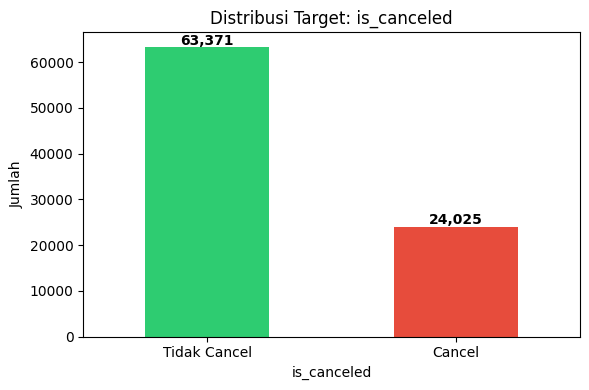


Rasio Cancel: 27.5%
Dataset cukup seimbang, tidak perlu SMOTE.
Tapi tetap gunakan class_weight='balanced' di Random Forest
untuk meningkatkan recall pada kelas cancel.


In [6]:
# =====================================================
# CELL 6 - TARGET DISTRIBUTION
# =====================================================

target_dist = df['is_canceled'].value_counts()
target_pct = df['is_canceled'].value_counts(normalize=True) * 100

print("Distribusi Target:\n")
print(f"Tidak Cancel (0): {target_dist[0]} ({target_pct[0]:.1f}%)")
print(f"Cancel (1)      : {target_dist[1]} ({target_pct[1]:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
target_dist.plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('Distribusi Target: is_canceled')
ax.set_xticklabels(['Tidak Cancel', 'Cancel'], rotation=0)
ax.set_ylabel('Jumlah')

for i, v in enumerate(target_dist):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRasio Cancel: {target_pct[1]:.1f}%")
print("Dataset cukup seimbang, tidak perlu SMOTE.")
print("Tapi tetap gunakan class_weight='balanced' di Random Forest")
print("untuk meningkatkan recall pada kelas cancel.")

In [7]:
# =====================================================
# CELL 7 - FEATURE ENGINEERING
# =====================================================

# total_stay: total lama menginap
df["total_stay"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

# total_guests: total tamu
df["total_guests"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

# revenue_estimate: estimasi pendapatan
df["revenue_estimate"] = df["adr"] * df["total_stay"]

# is_agent_booking: apakah booking melalui agen
df["is_agent_booking"] = (
    df["agent"].notna().astype(int)
)

print("Feature engineering berhasil.\n")
display(
    df[["total_stay", "total_guests",
        "revenue_estimate", "is_agent_booking"]].head()
)

Feature engineering berhasil.



,total_stay,total_guests,revenue_estimate,is_agent_booking
0,0,2.0,0.0,0
1,0,2.0,0.0,0
2,1,1.0,75.0,0
3,1,1.0,75.0,1
4,2,2.0,196.0,1


In [8]:
# =====================================================
# CELL 8 - DROP FITUR TIDAK LAYAK
# =====================================================

# reservation_status      -> DATA LEAKAGE (jawaban akhir)
# reservation_status_date -> DATA LEAKAGE (tanggal akhir)
# assigned_room_type      -> baru diketahui saat check-in
# agent                   -> identifier, 14% missing
# company                 -> identifier, 94% missing
# arrival_date_year       -> hanya 3 nilai (2015-2017)
# arrival_date_month      -> akan diganti month number
# arrival_date_day_of_month -> noise
# arrival_date_week_number  -> noise

# Konversi bulan ke angka sebelum di-drop
month_map = {
    'January': 1, 'February': 2, 'March': 3,
    'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9,
    'October': 10, 'November': 11, 'December': 12
}

df["arrival_month"] = df["arrival_date_month"].map(month_map)

columns_to_drop = [
    "reservation_status",
    "reservation_status_date",
    "assigned_room_type",
    "agent",
    "company",
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_day_of_month",
    "arrival_date_week_number",
    # drop komponen yang sudah di-aggregate
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies"
]

df_ml = df.drop(columns=columns_to_drop)

print("Kolom yang di-drop:")
for c in columns_to_drop:
    print(f"  - {c}")

print(f"\nShape sebelum: {df.shape}")
print(f"Shape sesudah: {df_ml.shape}")
print(f"\nKolom tersisa: {list(df_ml.columns)}")

Kolom yang di-drop:
  - reservation_status
  - reservation_status_date
  - assigned_room_type
  - agent
  - company
  - arrival_date_year
  - arrival_date_month
  - arrival_date_day_of_month
  - arrival_date_week_number
  - stays_in_weekend_nights
  - stays_in_week_nights
  - adults
  - children
  - babies

Shape sebelum: (87396, 37)
Shape sesudah: (87396, 23)

Kolom tersisa: ['hotel', 'is_canceled', 'lead_time', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'booking_changes', 'deposit_type', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_stay', 'total_guests', 'revenue_estimate', 'is_agent_booking', 'arrival_month']


In [9]:
# =====================================================
# CELL 9 - GROUPING COUNTRY
# =====================================================

# 177 negara terlalu banyak untuk one-hot encoding
# Grouping: top 10 negara + "Other"

top_countries = (
    df_ml["country"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

df_ml["country_grouped"] = df_ml["country"].apply(
    lambda x: x if x in top_countries else "Other"
)

print("Top 10 negara yang dipertahankan:")
display(df_ml["country_grouped"].value_counts())

df_ml = df_ml.drop(columns=["country"])

print(f"\nShape: {df_ml.shape}")

Top 10 negara yang dipertahankan:


country_grouped
PRT      27453
Other    15965
GBR      10433
FRA       8837
ESP       7252
DEU       5387
ITA       3066
IRL       3016
BEL       2081
BRA       1995
NLD       1911
Name: count, dtype: int64


Shape: (87396, 23)


In [10]:
# =====================================================
# CELL 10 - SAVE PREPROCESSED DATA
# =====================================================

df_ml.to_csv("HotelBooking_Clean.csv", index=False)

print(f"Dataset bersih disimpan: HotelBooking_Clean.csv")
print(f"Jumlah Data : {len(df_ml)}")
print(f"Jumlah Kolom: {df_ml.shape[1]}")
print(f"\nKolom:")
for i, col in enumerate(df_ml.columns, 1):
    print(f"  {i}. {col}")

Dataset bersih disimpan: HotelBooking_Clean.csv
Jumlah Data : 87396
Jumlah Kolom: 23

Kolom:
  1. hotel
  2. is_canceled
  3. lead_time
  4. meal
  5. market_segment
  6. distribution_channel
  7. is_repeated_guest
  8. previous_cancellations
  9. previous_bookings_not_canceled
  10. reserved_room_type
  11. booking_changes
  12. deposit_type
  13. days_in_waiting_list
  14. customer_type
  15. adr
  16. required_car_parking_spaces
  17. total_of_special_requests
  18. total_stay
  19. total_guests
  20. revenue_estimate
  21. is_agent_booking
  22. arrival_month
  23. country_grouped


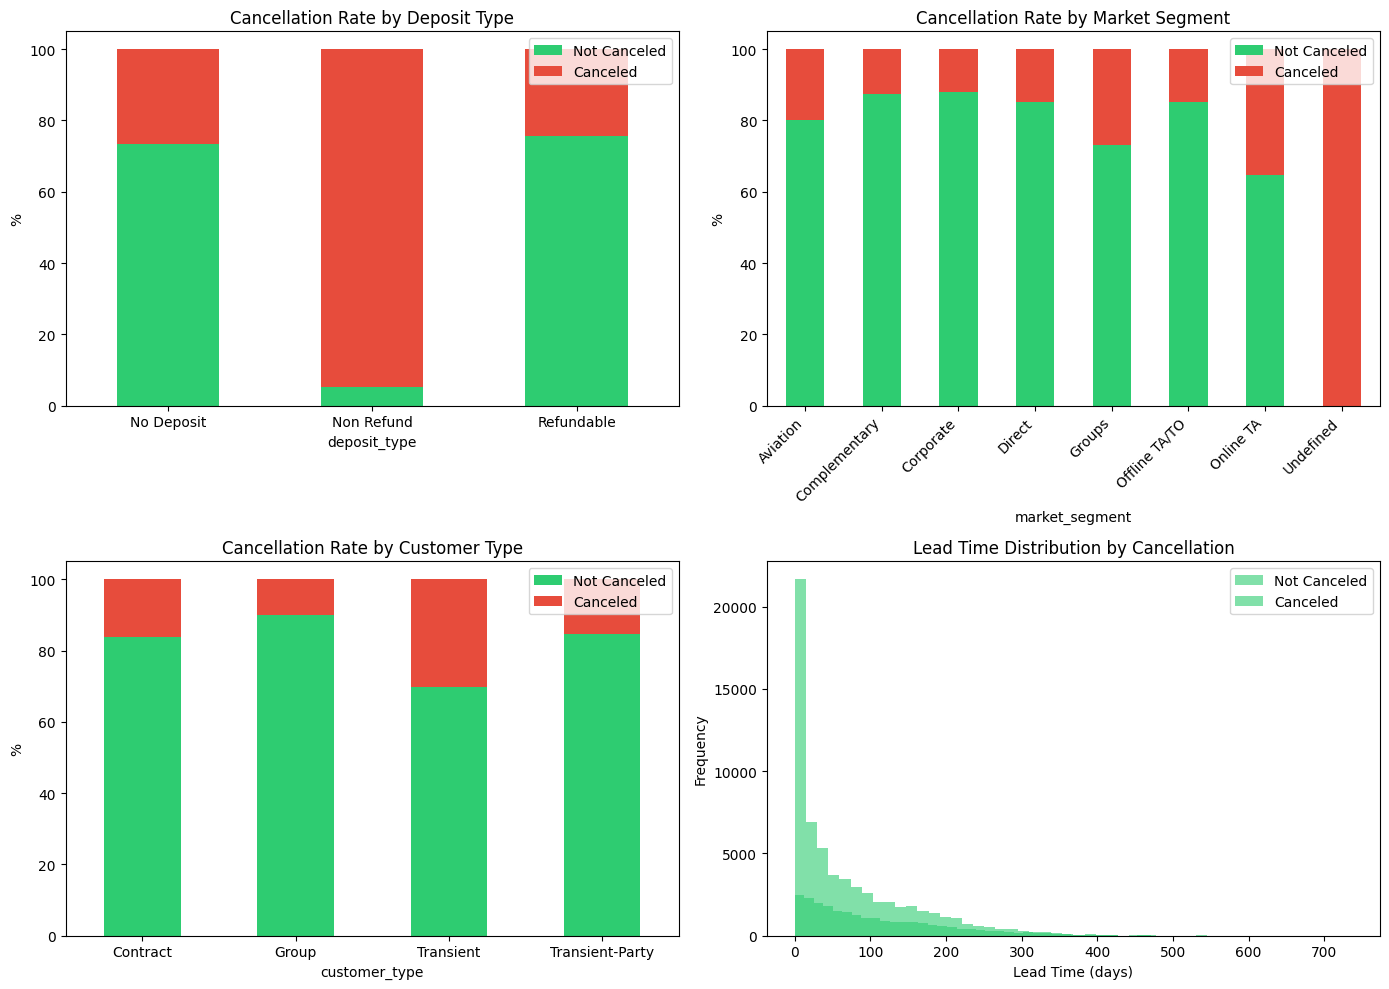

In [11]:
# =====================================================
# CELL 11 - EDA: FAKTOR PEMBATALAN
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Deposit Type vs Cancellation
ct1 = pd.crosstab(df_ml['deposit_type'], df_ml['is_canceled'], normalize='index') * 100
ct1.plot(kind='bar', stacked=True, ax=axes[0, 0], color=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Cancellation Rate by Deposit Type')
axes[0, 0].set_ylabel('%')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)
axes[0, 0].legend(['Not Canceled', 'Canceled'])

# 2. Market Segment vs Cancellation
ct2 = pd.crosstab(df_ml['market_segment'], df_ml['is_canceled'], normalize='index') * 100
ct2.plot(kind='bar', stacked=True, ax=axes[0, 1], color=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title('Cancellation Rate by Market Segment')
axes[0, 1].set_ylabel('%')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right')
axes[0, 1].legend(['Not Canceled', 'Canceled'])

# 3. Customer Type vs Cancellation
ct3 = pd.crosstab(df_ml['customer_type'], df_ml['is_canceled'], normalize='index') * 100
ct3.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Cancellation Rate by Customer Type')
axes[1, 0].set_ylabel('%')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
axes[1, 0].legend(['Not Canceled', 'Canceled'])

# 4. Lead Time distribution
df_ml.groupby('is_canceled')['lead_time'].plot(
    kind='hist', alpha=0.6, bins=50, ax=axes[1, 1],
    legend=True, color=['#2ecc71', '#e74c3c']
)
axes[1, 1].set_title('Lead Time Distribution by Cancellation')
axes[1, 1].set_xlabel('Lead Time (days)')
axes[1, 1].legend(['Not Canceled', 'Canceled'])

plt.tight_layout()
plt.show()

Korelasi fitur numerik dengan is_canceled:



lead_time                         0.1848
required_car_parking_spaces      -0.1842
revenue_estimate                  0.1395
is_agent_booking                  0.1328
adr                               0.1280
total_of_special_requests        -0.1205
total_guests                      0.1003
booking_changes                  -0.0936
is_repeated_guest                -0.0896
total_stay                        0.0841
previous_bookings_not_canceled   -0.0522
previous_cancellations            0.0515
days_in_waiting_list              0.0045
arrival_month                     0.0037
Name: is_canceled, dtype: float64

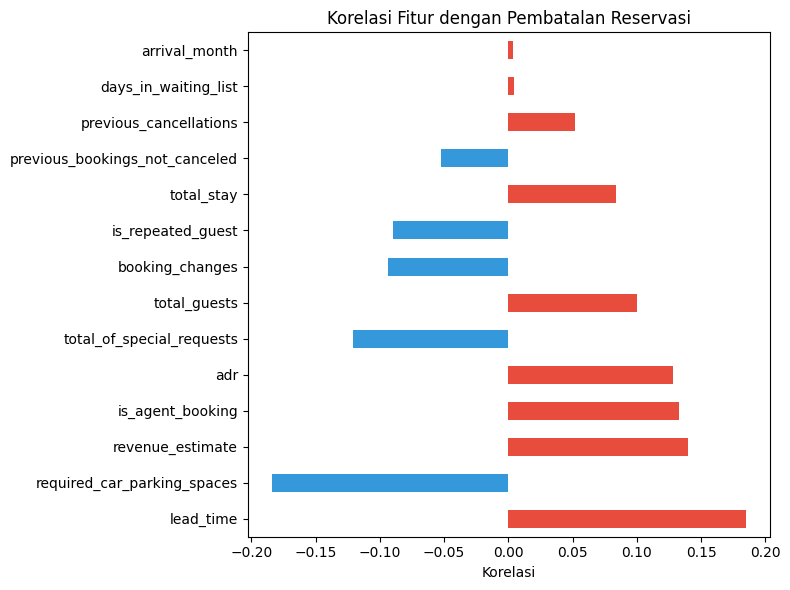

In [12]:
# =====================================================
# CELL 12 - CORRELATION ANALYSIS
# =====================================================

numeric_cols = df_ml.select_dtypes(include=[np.number]).columns
corr_with_target = (
    df_ml[numeric_cols]
    .corr()["is_canceled"]
    .drop("is_canceled")
    .sort_values(key=abs, ascending=False)
)

print("Korelasi fitur numerik dengan is_canceled:\n")
display(corr_with_target.round(4))

fig, ax = plt.subplots(figsize=(8, 6))
corr_with_target.plot(kind='barh', ax=ax, color=[
    '#e74c3c' if x > 0 else '#3498db' for x in corr_with_target
])
ax.set_title('Korelasi Fitur dengan Pembatalan Reservasi')
ax.set_xlabel('Korelasi')
plt.tight_layout()
plt.show()

In [13]:
# =====================================================
# CELL 13 - ENCODING (ONE-HOT)
# =====================================================

categorical_cols = df_ml.select_dtypes(include=['object']).columns.tolist()

print("Kolom kategorikal yang akan di-encode:")
for col in categorical_cols:
    n_unique = df_ml[col].nunique()
    print(f"  - {col} ({n_unique} kategori)")

df_encoded = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True)

print(f"\nShape sebelum encoding: {df_ml.shape}")
print(f"Shape setelah encoding: {df_encoded.shape}")

Kolom kategorikal yang akan di-encode:
  - hotel (2 kategori)
  - meal (5 kategori)
  - market_segment (8 kategori)
  - distribution_channel (5 kategori)
  - reserved_room_type (10 kategori)
  - deposit_type (3 kategori)
  - customer_type (4 kategori)
  - country_grouped (11 kategori)

Shape sebelum encoding: (87396, 23)
Shape setelah encoding: (87396, 55)


In [14]:
# =====================================================
# CELL 14 - FEATURE & TARGET SPLIT
# =====================================================

X = df_encoded.drop(columns=["is_canceled"])
y = df_encoded["is_canceled"]

print(f"Jumlah Feature: {X.shape[1]}")
print(f"Jumlah Data   : {X.shape[0]}")
print(f"\nDaftar fitur ({X.shape[1]} total):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")

Jumlah Feature: 54
Jumlah Data   : 87396

Daftar fitur (54 total):
  1. lead_time
  2. is_repeated_guest
  3. previous_cancellations
  4. previous_bookings_not_canceled
  5. booking_changes
  6. days_in_waiting_list
  7. adr
  8. required_car_parking_spaces
  9. total_of_special_requests
  10. total_stay
  11. total_guests
  12. revenue_estimate
  13. is_agent_booking
  14. arrival_month
  15. hotel_Resort Hotel
  16. meal_FB
  17. meal_HB
  18. meal_SC
  19. meal_Undefined
  20. market_segment_Complementary
  21. market_segment_Corporate
  22. market_segment_Direct
  23. market_segment_Groups
  24. market_segment_Offline TA/TO
  25. market_segment_Online TA
  26. market_segment_Undefined
  27. distribution_channel_Direct
  28. distribution_channel_GDS
  29. distribution_channel_TA/TO
  30. distribution_channel_Undefined
  31. reserved_room_type_B
  32. reserved_room_type_C
  33. reserved_room_type_D
  34. reserved_room_type_E
  35. reserved_room_type_F
  36. reserved_room_type_G
  37.

In [15]:
# =====================================================
# CELL 15 - TRAIN TEST SPLIT (80/20)
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training : {X_train.shape}")
print(f"Testing  : {X_test.shape}")
print(f"\nDistribusi target di Training:")
print(y_train.value_counts())
print(f"\nDistribusi target di Testing:")
print(y_test.value_counts())

Training : (69916, 54)
Testing  : (17480, 54)

Distribusi target di Training:
is_canceled
0    50696
1    19220
Name: count, dtype: int64

Distribusi target di Testing:
is_canceled
0    12675
1     4805
Name: count, dtype: int64


In [16]:
# =====================================================
# CELL 16 - FEATURE SCALING
# =====================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling selesai.")
print(f"Shape X_train_scaled: {X_train_scaled.shape}")

Feature scaling selesai.
Shape X_train_scaled: (69916, 54)


In [17]:
# =====================================================
# CELL 17 - 10-FOLD STRATIFIED CROSS VALIDATION
# =====================================================

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Cross-validation Random Forest
print("Running 10-Fold CV untuk Random Forest...")
rf_cv = cross_validate(
    RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    X_train, y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# Cross-validation Neural Network
print("Running 10-Fold CV untuk Neural Network...")
nn_cv = cross_validate(
    MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        random_state=42
    ),
    X_train_scaled, y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

cv_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"],
    "RF Mean": [
        rf_cv[f'test_{s}'].mean()
        for s in scoring
    ],
    "RF Std": [
        rf_cv[f'test_{s}'].std()
        for s in scoring
    ],
    "NN Mean": [
        nn_cv[f'test_{s}'].mean()
        for s in scoring
    ],
    "NN Std": [
        nn_cv[f'test_{s}'].std()
        for s in scoring
    ]
})

print("\n===== HASIL 10-FOLD CROSS VALIDATION =====\n")
display(cv_results.round(4))

Running 10-Fold CV untuk Random Forest...
Running 10-Fold CV untuk Neural Network...

===== HASIL 10-FOLD CROSS VALIDATION =====



,Metric,RF Mean,RF Std,NN Mean,NN Std
0,Accuracy,0.8207,0.0045,0.7990,0.0058
1,Precision,0.6570,0.0073,0.6374,0.0167
2,Recall,0.7279,0.0105,0.6269,0.0224
3,F1-Score,0.6906,0.0081,0.6316,0.0092
4,AUC,0.8855,0.0034,0.8553,0.0057


In [38]:
# =====================================================
# CELL 18 - RANDOM FOREST TRAINING
# =====================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest berhasil dilatih.")
print(f"Jumlah trees: {rf_model.n_estimators}")
print(f"Class weight: balanced")

Random Forest berhasil dilatih.
Jumlah trees: 200
Class weight: balanced


In [39]:
# =====================================================
# CELL 19 - NEURAL NETWORK TRAINING
# =====================================================

nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=500,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)

print("Neural Network berhasil dilatih.")
print(f"Hidden layers: (128, 64)")
print(f"Iterasi: {nn_model.n_iter_}")

Neural Network berhasil dilatih.
Hidden layers: (128, 64)
Iterasi: 382


In [40]:
# =====================================================
# CELL 20 - MODEL EVALUATION
# =====================================================

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

nn_pred = nn_model.predict(X_test_scaled)
nn_proba = nn_model.predict_proba(X_test_scaled)[:, 1]

results = pd.DataFrame({
    "Model": ["Random Forest", "Neural Network"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, nn_pred)
    ],
    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, nn_pred)
    ],
    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, nn_pred)
    ],
    "F1-Score": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, nn_pred)
    ],
    "AUC": [
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, nn_proba)
    ],
    "MCC": [
        matthews_corrcoef(y_test, rf_pred),
        matthews_corrcoef(y_test, nn_pred)
    ]
})

print("===== EVALUASI MODEL (TEST SET) =====\n")
display(results.round(4))

===== EVALUASI MODEL (TEST SET) =====



,Model,Accuracy,Precision,Recall,F1-Score,AUC,MCC
0,Random Forest,0.8196,0.6551,0.7261,0.6888,0.8856,0.5637
1,Neural Network,0.7991,0.6442,0.6015,0.6221,0.8556,0.4861


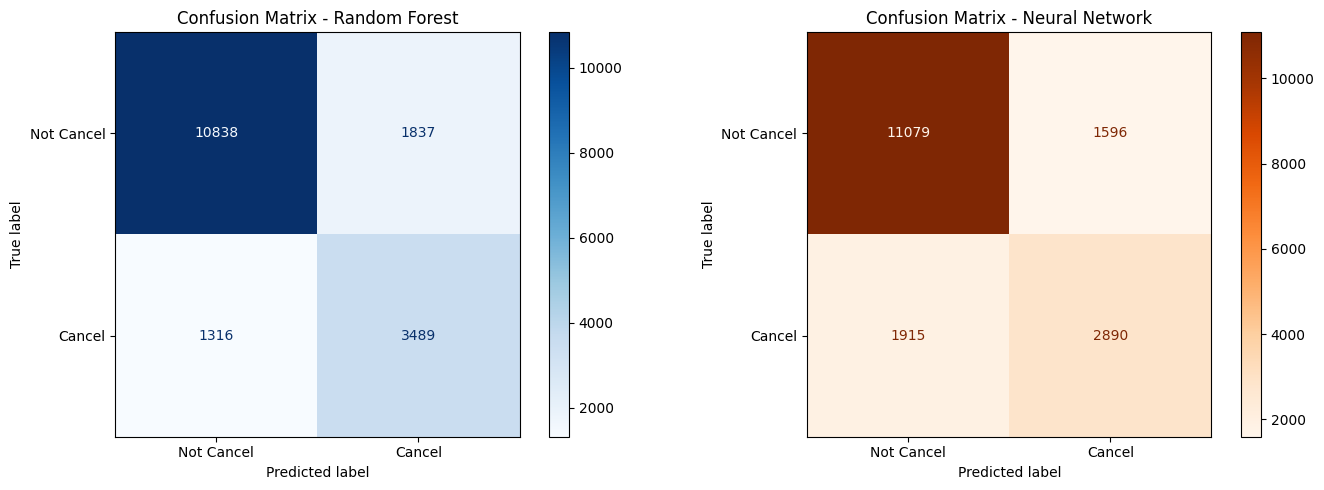


===== Classification Report - Random Forest =====

              precision    recall  f1-score   support

  Not Cancel       0.89      0.86      0.87     12675
      Cancel       0.66      0.73      0.69      4805

    accuracy                           0.82     17480
   macro avg       0.77      0.79      0.78     17480
weighted avg       0.83      0.82      0.82     17480


===== Classification Report - Neural Network =====

              precision    recall  f1-score   support

  Not Cancel       0.85      0.87      0.86     12675
      Cancel       0.64      0.60      0.62      4805

    accuracy                           0.80     17480
   macro avg       0.75      0.74      0.74     17480
weighted avg       0.80      0.80      0.80     17480



In [41]:
# =====================================================
# CELL 21 - CONFUSION MATRIX
# =====================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=["Not Cancel", "Cancel"],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title("Confusion Matrix - Random Forest")

# Neural Network
ConfusionMatrixDisplay.from_predictions(
    y_test, nn_pred,
    display_labels=["Not Cancel", "Cancel"],
    cmap='Oranges', ax=axes[1]
)
axes[1].set_title("Confusion Matrix - Neural Network")

plt.tight_layout()
plt.show()

# Detail per kelas
print("\n===== Classification Report - Random Forest =====\n")
print(classification_report(
    y_test, rf_pred,
    target_names=["Not Cancel", "Cancel"]
))

print("\n===== Classification Report - Neural Network =====\n")
print(classification_report(
    y_test, nn_pred,
    target_names=["Not Cancel", "Cancel"]
))

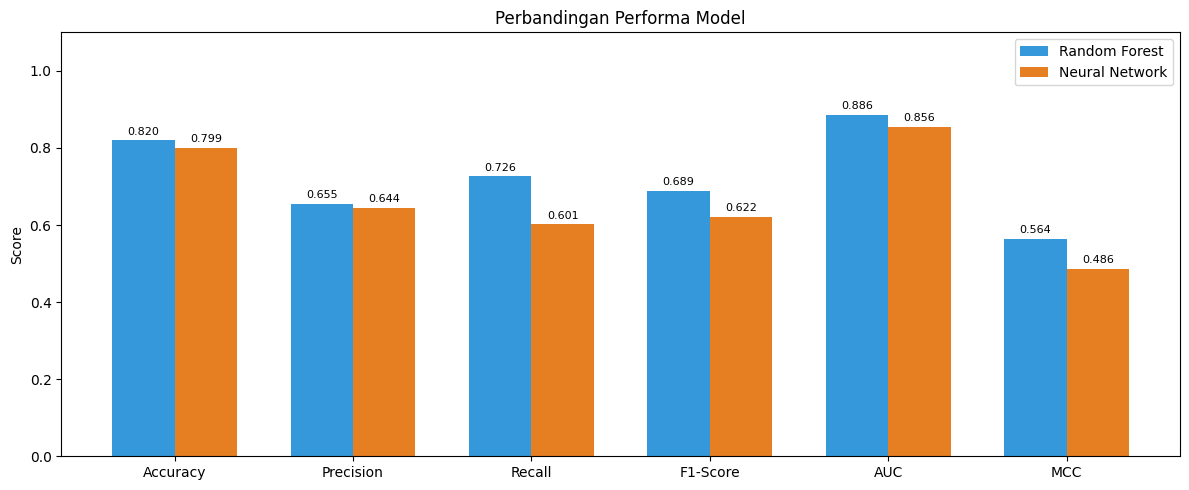


Model Terbaik: Random Forest
F1-Score: 0.6888
AUC: 0.8856


In [42]:
# =====================================================
# CELL 22 - MODEL COMPARISON CHART
# =====================================================

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC", "MCC"]
rf_scores = results[metrics].iloc[0].values
nn_scores = results[metrics].iloc[1].values

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, rf_scores, width, label='Random Forest', color='#3498db')
bars2 = ax.bar(x + width/2, nn_scores, width, label='Neural Network', color='#e67e22')

ax.set_ylabel('Score')
ax.set_title('Perbandingan Performa Model')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

best = results.loc[results["F1-Score"].idxmax()]
print(f"\nModel Terbaik: {best['Model']}")
print(f"F1-Score: {best['F1-Score']:.4f}")
print(f"AUC: {best['AUC']:.4f}")

Top 15 fitur terpenting:



,Feature,Importance
0,lead_time,0.178621
6,adr,0.114748
11,revenue_estimate,0.113368
13,arrival_month,0.069551
53,country_grouped_PRT,0.061507
8,total_of_special_requests,0.060110
7,required_car_parking_spaces,0.047466
9,total_stay,0.047379
24,market_segment_Online TA,0.032431
10,total_guests,0.023622


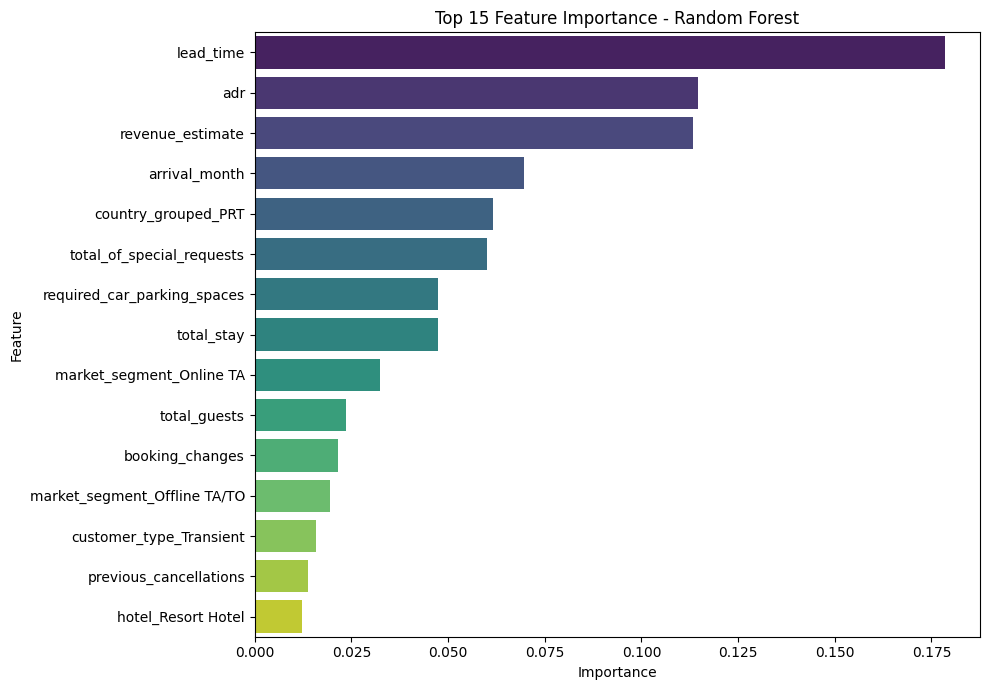

In [43]:
# =====================================================
# CELL 23 - FEATURE IMPORTANCE
# =====================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Top 15 fitur terpenting:\n")
display(importance.head(15))

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=importance.head(15),
    x="Importance", y="Feature",
    palette="viridis", ax=ax
)
ax.set_title("Top 15 Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

In [45]:
# =====================================================
# CELL 24 - SAVE MODEL
# =====================================================

joblib.dump(rf_model, "hotel_model_rf.pkl", compress=3)
joblib.dump(nn_model, "hotel_model_nn.pkl", compress=3)
joblib.dump(scaler, "hotel_scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")
joblib.dump(results, "model_metrics.pkl")

import os
rf_size = os.path.getsize("hotel_model_rf.pkl") / (1024*1024)
nn_size = os.path.getsize("hotel_model_nn.pkl") / (1024*1024)

print("Model berhasil disimpan.\n")
print(f"hotel_model_rf.pkl   : {rf_size:.1f} MB")
print(f"hotel_model_nn.pkl   : {nn_size:.1f} MB")
print(f"hotel_scaler.pkl     : saved")
print(f"feature_columns.pkl  : saved ({len(X.columns)} fitur)")
print(f"model_metrics.pkl    : saved")

Model berhasil disimpan.

hotel_model_rf.pkl   : 69.2 MB
hotel_model_nn.pkl   : 0.5 MB
hotel_scaler.pkl     : saved
feature_columns.pkl  : saved (54 fitur)
model_metrics.pkl    : saved


In [46]:
# =====================================================
# CELL 25 - PREDICTION SIMULATION
# =====================================================

sample = X_test.iloc[[0]]
actual = y_test.iloc[0]

pred = rf_model.predict(sample)
proba = rf_model.predict_proba(sample)

status = "Cancel" if pred[0] == 1 else "Tidak Cancel"
actual_status = "Cancel" if actual == 1 else "Tidak Cancel"

print("===== SIMULASI PREDIKSI =====\n")
print(f"Prediksi Model  : {status}")
print(f"Nilai Aktual    : {actual_status}")
print(f"Probabilitas Cancel     : {proba[0][1]:.2%}")
print(f"Probabilitas Tidak Cancel: {proba[0][0]:.2%}")

===== SIMULASI PREDIKSI =====

Prediksi Model  : Tidak Cancel
Nilai Aktual    : Tidak Cancel
Probabilitas Cancel     : 42.88%
Probabilitas Tidak Cancel: 57.12%
